# PCA Feature Extraction

In this notebook, we will implement Principal Component Analysis (PCA) from scratch and apply it to extract features from the face dataset.

**Objectives:**
1. Implement PCA from scratch (without using sklearn.decomposition.PCA)
2. Apply PCA with 2 and 3 components for visualization
3. Apply PCA with 100 and 300 components for Part 2 preparation
4. Visualize eigenfaces and projected data
5. Highlight selfie samples in visualizations

In [1]:
import os
import sys
import numpy as np
import traceback
from pathlib import Path
from typing import Tuple
from matplotlib import pyplot as plt

sys.path.append(str(Path().absolute().parent))

from src.data.data_loader import load_config
from src.preprocessing.pca import compute_pca
from src.visualization.plotter import (
    plot_pca_2d, plot_pca_3d, plot_eigenfaces
)

## Load Configuration and Data

In [2]:
config = load_config()
print(f"Using seed value: {config['seed']}")

try:
    #load processed data
    
    x_train = np.load('../Outputs/data/x_train.npy')
    y_train = np.load('../Outputs/data/y_train.npy')
    train_selfie_indices = np.load('../Outputs/data/train_selfie_indices.npy')
    
    print(f"Loaded training data: {x_train.shape}")
    print(f"Training labels: {y_train.shape}")
    print(f"Number of selfie samples in training: {len(train_selfie_indices)}")
    
except Exception as e:
    print(f"Error loading data: {e}")
    print(traceback.format_exc(limit=3))

Using seed value: 963
Loaded training data: (2978, 1024)
Training labels: (2978,)
Number of selfie samples in training: 7


## Part I: PCA for Visualization

### PCA with 2 Components

In [3]:
try:
    print("Computing PCA with 2 components for 2D visualization...")
    
    pca_vectors_2, x_train_pca_2 = compute_pca(x_train, 2)
    
    print(f"PCA vectors shape: {pca_vectors_2.shape}")
    print(f"Transformed data shape: {x_train_pca_2.shape}")
    
    # Calculate explained variance
    cov_matrix = np.cov(x_train.T)
    eigenvalues = np.linalg.eigvals(cov_matrix)
    explained_variance_ratio = eigenvalues[:2] / np.sum(eigenvalues)
    print(f"Explained variance ratio (2 components): {explained_variance_ratio}")
    
except Exception as e:
    print(f"Error in PCA with 2 components: {e}")
    print(traceback.format_exc(limit=3))

Computing PCA with 2 components for 2D visualization...
PCA vectors shape: (1024, 2)
Transformed data shape: (2978, 2)
Explained variance ratio (2 components): [0.44105834 0.23652591]


In [ ]:
try:
    # Create output directory
    os.makedirs('../Outputs/pca', exist_ok=True)
    
    # Visualize 2D PCA projection
    plot_pca_2d(x_train_pca_2, y_train, train_selfie_indices,
               save_path="../Outputs/pca/pca_2d_visualization.png", show=False)
    print("2D PCA visualization saved to ../Outputs/pca/pca_2d_visualization.png")
    
    # Visualize eigenfaces (2 components)
    plot_eigenfaces(pca_vectors_2, n_components=2,
                   save_path='../Outputs/pca/eigenfaces_2.png', show=False)
    print("Eigenfaces (2 components) saved to ../Outputs/pca/eigenfaces_2.png")
    
    # Save PCA 2-component features for LDA comparison
    os.makedirs('../Outputs/features', exist_ok=True)
    np.save('../Outputs/features/pca_2_features.npy', x_train_pca_2)
    np.save('../Outputs/features/pca_2_vectors.npy', pca_vectors_2)
    print("PCA 2-component features saved to ../Outputs/features/ for LDA comparison")
    
except Exception as e:
    print(f"Error visualizing 2D PCA results: {e}")
    print(traceback.format_exc(limit=3))

### PCA with 3 Components

In [5]:
try:
    print("Computing PCA with 3 components for 3D visualization...")
    
    pca_vectors_3, x_train_pca_3 = compute_pca(x_train, 3)
    
    print(f"PCA vectors shape: {pca_vectors_3.shape}")
    print(f"Transformed data shape: {x_train_pca_3.shape}")
    
    # Calculate explained variance
    explained_variance_ratio = eigenvalues[:3] / np.sum(eigenvalues)
    print(f"Explained variance ratio (3 components): {explained_variance_ratio}")
    print(f"Total explained variance: {np.sum(explained_variance_ratio):.4f}")
    
except Exception as e:
    print(f"Error in PCA with 3 components: {e}")
    print(traceback.format_exc(limit=3))

Computing PCA with 3 components for 3D visualization...
PCA vectors shape: (1024, 3)
Transformed data shape: (2978, 3)
Explained variance ratio (3 components): [0.44105834 0.23652591 0.06666272]
Total explained variance: 0.7442


In [ ]:
try:
    # Visualize 3D PCA projection
    plot_pca_3d(x_train_pca_3, y_train, train_selfie_indices,
               save_path='../Outputs/pca/pca_3d_visualization.png', show=False)
    print("3D PCA visualization saved to ../Outputs/pca/pca_3d_visualization.png")
    
    # Visualize eigenfaces (3 components)
    plot_eigenfaces(pca_vectors_3, n_components=3,
                   save_path='../Outputs/pca/eigenfaces_3.png', show=False)
    print("Eigenfaces (3 components) saved to ../Outputs/pca/eigenfaces_3.png")
    
    # Save PCA 3-component features for future use
    np.save('../Outputs/features/pca_3_features.npy', x_train_pca_3)
    np.save('../Outputs/features/pca_3_vectors.npy', pca_vectors_3)
    print("PCA 3-component features saved to ../Outputs/features/ for future use")
    
except Exception as e:
    print(f"Error visualizing 3D PCA results: {e}")
    print(traceback.format_exc(limit=3))

## Part II: PCA for Feature Extraction (Preparation for Part 2)

### PCA with 100 Components

In [7]:
try:
    print("Computing PCA with 100 components for feature extraction...")
    
    pca_vectors_100, x_train_pca_100 = compute_pca(x_train, 100)
    
    print(f"PCA vectors shape: {pca_vectors_100.shape}")
    print(f"Transformed data shape: {x_train_pca_100.shape}")
    
    # Calculate explained variance
    explained_variance_ratio = eigenvalues[:100] / np.sum(eigenvalues)
    print(f"Total explained variance (100 components): {np.sum(explained_variance_ratio):.4f}")
    
except Exception as e:
    print(f"Error in PCA with 100 components: {e}")
    print(traceback.format_exc(limit=3))

Computing PCA with 100 components for feature extraction...
PCA vectors shape: (1024, 100)
Transformed data shape: (2978, 100)
Total explained variance (100 components): 0.9744


### PCA with 300 Components

In [8]:
try:
    print("Computing PCA with 300 components for feature extraction...")
    
    pca_vectors_300, x_train_pca_300 = compute_pca(x_train, 300)
    
    print(f"PCA vectors shape: {pca_vectors_300.shape}")
    print(f"Transformed data shape: {x_train_pca_300.shape}")
    
    # Calculate explained variance
    explained_variance_ratio = eigenvalues[:300] / np.sum(eigenvalues)
    print(f"Total explained variance (300 components): {np.sum(explained_variance_ratio):.4f}")
    
except Exception as e:
    print(f"Error in PCA with 300 components: {e}")
    print(traceback.format_exc(limit=3))

Computing PCA with 300 components for feature extraction...
PCA vectors shape: (1024, 300)
Transformed data shape: (2978, 300)
Total explained variance (300 components): 0.9939


## Save PCA Features for Part 2

In [ ]:
#save all pca features and vectors
try:
    os.makedirs('../Outputs/features', exist_ok=True)
    
    np.save('../Outputs/features/pca_2_features.npy', x_train_pca_2)
    np.save('../Outputs/features/pca_2_vectors.npy', pca_vectors_2)
    print("PCA features (2 components) saved to ../Outputs/features/")

    np.save('../Outputs/features/pca_3_features.npy', x_train_pca_3)
    np.save('../Outputs/features/pca_3_vectors.npy', pca_vectors_3)
    print("PCA features (3 components) saved to ../Outputs/features/")
    
    np.save('../Outputs/features/pca_100_features.npy', x_train_pca_100)
    np.save('../Outputs/features/pca_100_vectors.npy', pca_vectors_100)
    print("PCA features (100 components) saved to ../Outputs/features/")
    
    np.save('../Outputs/features/pca_300_features.npy', x_train_pca_300)
    np.save('../Outputs/features/pca_300_vectors.npy', pca_vectors_300)
    print("PCA features (300 components) saved to ../Outputs/features/")
    
except Exception as e:
    print(f"Error saving PCA features: {e}")
    print(traceback.format_exc(limit=3))

PCA features (2 components) saved to ../Outputs/features/
PCA features (3 components) saved to ../Outputs/features/
PCA features (100 components) saved to ../Outputs/features/
PCA features (300 components) saved to ../Outputs/features/


## Analyze PCA Results

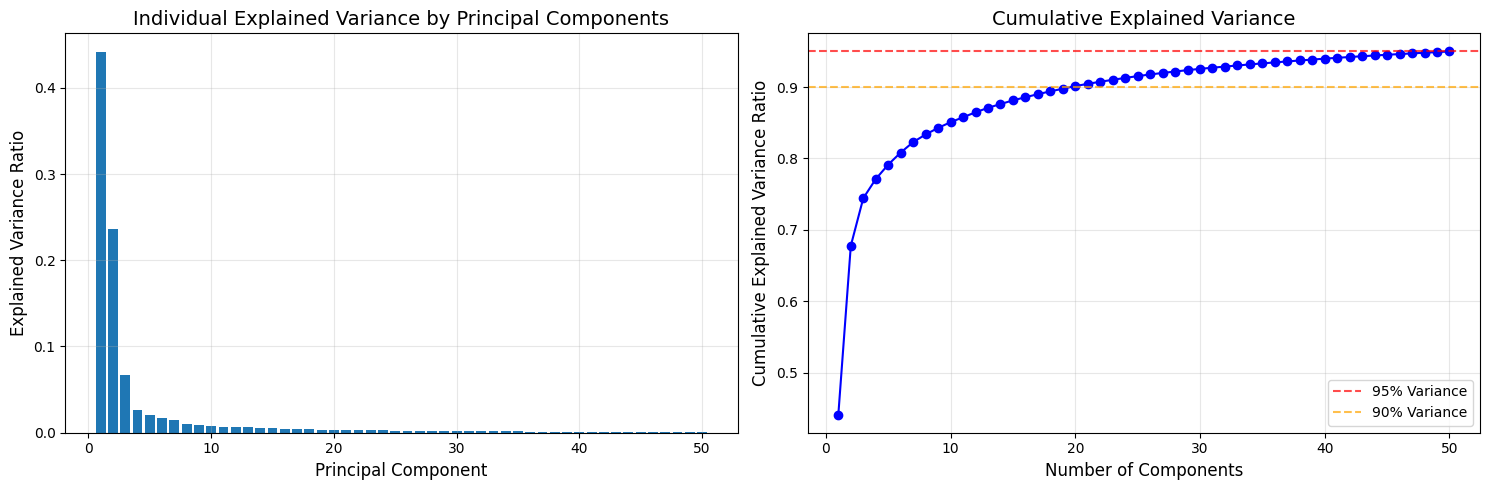

Number of components needed for 90% variance: 20
Number of components needed for 95% variance: 51


In [11]:
try:
    #plot explained variance cumulative sum
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    #individual explained variance
    n_components_to_show = min(50, len(eigenvalues))
    individual_var_ratio = eigenvalues[:n_components_to_show] / np.sum(eigenvalues)
    
    ax1.bar(range(1, n_components_to_show + 1), individual_var_ratio)
    ax1.set_xlabel('Principal Component')
    ax1.set_ylabel('Explained Variance Ratio')
    ax1.set_title('Individual Explained Variance by Principal Components')
    ax1.grid(True, alpha=0.3)
    
    # cumulative explained variance
    cumulative_var_ratio = np.cumsum(individual_var_ratio)
    
    ax2.plot(range(1, n_components_to_show + 1), cumulative_var_ratio, 'bo-')
    ax2.set_xlabel('Number of Components')
    ax2.set_ylabel('Cumulative Explained Variance Ratio')
    ax2.set_title('Cumulative Explained Variance')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0.95, color='r', linestyle='--', alpha=0.7, label='95% Variance')
    ax2.axhline(y=0.90, color='orange', linestyle='--', alpha=0.7, label='90% Variance')
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig('../Outputs/pca/explained_variance_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    #find number of components needed for 95% variance
    cum_var_all = np.cumsum(eigenvalues / np.sum(eigenvalues))
    n_components_95 = np.argmax(cum_var_all >= 0.95) + 1
    n_components_90 = np.argmax(cum_var_all >= 0.90) + 1
    
    print(f"Number of components needed for 90% variance: {n_components_90}")
    print(f"Number of components needed for 95% variance: {n_components_95}")
    
except Exception as e:
    print(f"Error in PCA analysis: {e}")
    print(traceback.format_exc(limit=3))